# Section 24: RNNs (Recurrent Neural Networks) (and GRU/LSTM)

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

## The RNN class in PyTorch

In [2]:
input_size = 9
hidden_size = 16
layers_nr = 1
activation_function = 'tanh'
bias = True

rnn = nn.RNN(input_size, hidden_size, layers_nr, activation_function, bias)

print(rnn)

RNN(9, 16)


In [3]:
sequence_size = 5
batch_size = 2

X = torch.rand(sequence_size, batch_size, input_size)
hidden_layer = torch.zeros(layers_nr, batch_size, hidden_size)

y_pred, hidden_layer = rnn(X, hidden_layer)

print(f"Input shape: {list(X.shape)}")
print(f"Hidden shape: {list(hidden_layer.shape)}")
print(f"Output shape: {list(y_pred.shape)}")

Input shape: [5, 2, 9]
Hidden shape: [1, 2, 16]
Output shape: [5, 2, 16]


In [4]:
_, hidden_layer_1 = rnn(X, hidden_layer)

print(hidden_layer_1)

_, hidden_layer_2 = rnn(X)

print(hidden_layer_2)

print(hidden_layer_1 - hidden_layer_2)

tensor([[[ 0.6229, -0.3598,  0.6193, -0.5178,  0.3101, -0.3831, -0.0380,
          -0.0276,  0.0544, -0.1313,  0.1941, -0.2387, -0.3205, -0.0443,
           0.4501,  0.1593],
         [ 0.5354, -0.3604,  0.4311, -0.4070,  0.4509, -0.2670,  0.1295,
           0.0896,  0.1186, -0.1278,  0.2965, -0.2612, -0.0700, -0.0231,
           0.3159, -0.0520]]], grad_fn=<StackBackward0>)
tensor([[[ 0.6080, -0.3789,  0.6289, -0.5192,  0.3050, -0.3855, -0.0516,
          -0.0369,  0.0658, -0.1255,  0.1923, -0.2325, -0.3332, -0.0589,
           0.4528,  0.1644],
         [ 0.5183, -0.3772,  0.4425, -0.4052,  0.4475, -0.2731,  0.1153,
           0.0788,  0.1278, -0.1248,  0.2922, -0.2559, -0.0839, -0.0391,
           0.3182, -0.0410]]], grad_fn=<StackBackward0>)
tensor([[[ 0.0150,  0.0191, -0.0096,  0.0014,  0.0050,  0.0023,  0.0136,
           0.0093, -0.0114, -0.0059,  0.0018, -0.0062,  0.0126,  0.0146,
          -0.0026, -0.0051],
         [ 0.0171,  0.0168, -0.0114, -0.0018,  0.0034,  0.0061,  0.01

In [5]:
for p in rnn.named_parameters():
    if 'weight' in p[0]:
        print(f"{p[0]} has size {list(p[1].shape)}")

weight_ih_l0 has size [16, 9]
weight_hh_l0 has size [16, 16]


In [6]:
class RnnNet(nn.Module):
    def __init__(self, input_size_param, hidden_size_param, layers_nr_param, batch_size_param):
        super().__init__()
        
        self.input_size = input_size_param
        self.hidden_size = hidden_size_param
        self.layers_nr = layers_nr_param
        self.batch_size = batch_size_param
        
        self.rnn = nn.RNN(input_size_param, hidden_size_param, layers_nr_param)
        self.output = nn.Linear(hidden_size_param, 1)
        
    def forward(self, x_param):
        print(f"Input: {list(x_param.shape)}")
        
        hidden_layer_local = torch.zeros(self.layers_nr, self.batch_size, self.hidden_size)
        
        print(f"Hidden: {list(hidden_layer_local.shape)}")
        
        y_pred_local, hidden_layer_local = self.rnn(x_param, hidden_layer_local)
        
        print(f"RNN output: {list(y_pred_local.shape)}")
        print(f"RNN hidden: {list(hidden_layer_local.shape)}")
        
        output_local = self.output(y_pred_local)
        
        print(f"Output: {list(output_local.shape)}")
        
        return output_local, hidden_layer_local

In [7]:
rnn_net = RnnNet(input_size, hidden_size, layers_nr, batch_size)

print(rnn_net)

RnnNet(
  (rnn): RNN(9, 16)
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [8]:
for p in rnn_net.named_parameters():
    if 'weight' in p[0]:
        print(f"{p[0]} has size {list(p[1].shape)}")

rnn.weight_ih_l0 has size [16, 9]
rnn.weight_hh_l0 has size [16, 16]
output.weight has size [1, 16]


In [9]:
X = torch.rand(sequence_size, batch_size, input_size)
y = torch.rand(sequence_size, batch_size, 1)

y_pred, hidden_layer = rnn_net(X)

Input: [5, 2, 9]
Hidden: [1, 2, 16]
RNN output: [5, 2, 16]
RNN hidden: [1, 2, 16]
Output: [5, 2, 1]


In [10]:
loss_function = nn.MSELoss()

loss_function(y_pred, y)

tensor(0.3376, grad_fn=<MseLossBackward0>)

## Predicting alternating sequences

In [11]:
sequence_full_size = 50

data = torch.zeros(sequence_full_size)

for i in range(sequence_full_size):
    data[i] = torch.rand(1) * (-1) ** i

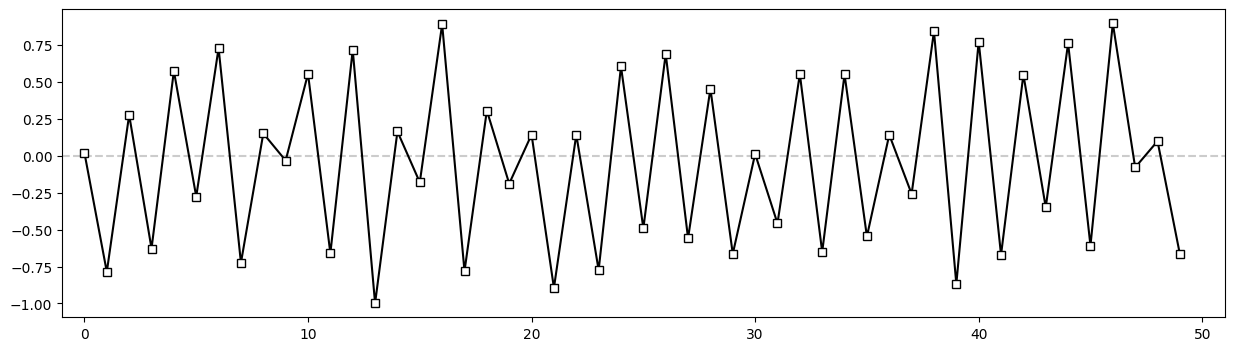

In [12]:
plt.figure(figsize=(15, 4))
plt.plot([-1, sequence_full_size + 1], [0, 0], '--', color=[.8, .8, .8])
plt.plot(data, 'ks-', markerfacecolor='w')
plt.xlim([-1, sequence_full_size + 1])
plt.show()

In [13]:
class RnnNet(nn.Module):
    def __init__(self, input_size_param, hidden_size_param, layers_nr_param):
        super().__init__()

        self.rnn = nn.RNN(input_size_param, hidden_size_param, layers_nr_param)
        self.output = nn.Linear(hidden_size_param, 1)

    def forward(self, x_param, hidden_param = None):
        y_pred_local, hidden_layer_local = self.rnn(x_param, hidden_param)
        output_local = self.output(y_pred_local)

        return output_local, hidden_layer_local.detach()

In [14]:
input_size = 1
hidden_size = 5
layers_nr = 1
sequence_size = 9
batch_size = 1

rnn_net = RnnNet(input_size, hidden_size, layers_nr)

In [15]:
X = torch.rand(sequence_size, batch_size, input_size)
y_pred, hidden_layer = rnn_net(X)

print(X.shape)
print(y_pred.shape)
print(hidden_layer.shape)

torch.Size([9, 1, 1])
torch.Size([9, 1, 1])
torch.Size([1, 1, 5])


In [16]:
y_pred  = rnn_net(data[:sequence_size].view(sequence_size, 1, 1))
y_pred = y_pred[0][-1]

loss_function = nn.MSELoss()

loss_function(y_pred, data[sequence_size].view(1, 1))

tensor(0.0033, grad_fn=<MseLossBackward0>)

In [17]:
epochs_nr = 30
rnn_net = RnnNet(input_size, hidden_size, layers_nr)
optimizer = torch.optim.SGD(rnn_net.parameters(), lr=.001)

losses = np.zeros(epochs_nr)
sign_accuracies = np.zeros(epochs_nr)

for epoch in range(epochs_nr):
    segment_losses = []
    segment_sign_accuracies = []
    
    for time_index in range(sequence_full_size - sequence_size):
        X = data[time_index:time_index + sequence_size].view(sequence_size, 1, 1)
        y = data[time_index + sequence_size].view(1, 1)
        
        y_pred, _ = rnn_net(X)
        y_pred = y_pred[-1]
        loss = loss_function(y_pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        segment_losses.append(loss.item())
        
        pred_signs = np.sign(torch.squeeze(y_pred).detach().numpy())
        true_signs = np.sign(torch.squeeze(y).numpy())
        segment_sign_accuracy = 100 * (true_signs == pred_signs)
        
        segment_sign_accuracies.append(segment_sign_accuracy)
        
    losses[epoch] = np.mean(segment_losses)
    sign_accuracies[epoch] = np.mean(segment_sign_accuracies)

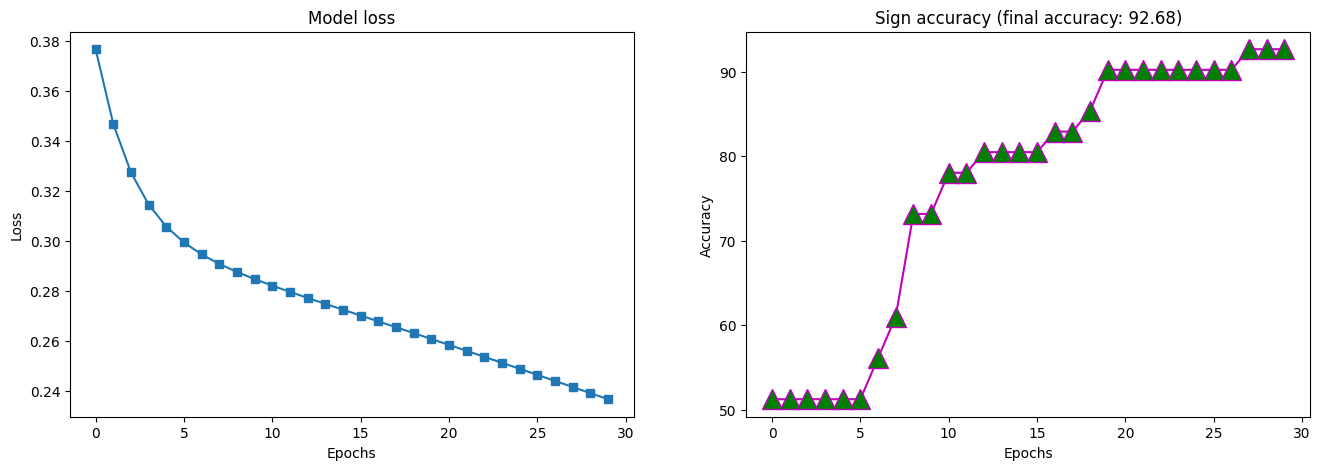

In [18]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(losses, 's-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")

ax[1].plot(sign_accuracies, 'm^-', markerfacecolor='g', markersize=15)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_title(f"Sign accuracy (final accuracy: {sign_accuracies[-1]:.2f})")

plt.show()

In [19]:
data_np = data.numpy().ravel()

hidden_layers = np.zeros((sequence_full_size, hidden_size))
y_pred = np.zeros(sequence_full_size)
y_pred[:] = np.nan

with torch.no_grad():
    for time_index in range(sequence_full_size - sequence_size):
        X = data[time_index:time_index + sequence_size].view(sequence_size, 1, 1)
        y_pred_temp, hidden_layer = rnn_net(X)
        y_pred[time_index + sequence_size] = y_pred_temp[-1].item()
        hidden_layers[time_index + sequence_size, :] = hidden_layer.numpy().ravel()

true_signs = np.sign(data_np)
pred_signs = np.sign(y_pred)
sign_accuracies = 100 * np.mean(true_signs[sequence_size:] == pred_signs[sequence_size:])

corr = np.corrcoef(data_np[sequence_size:], y_pred[sequence_size:])

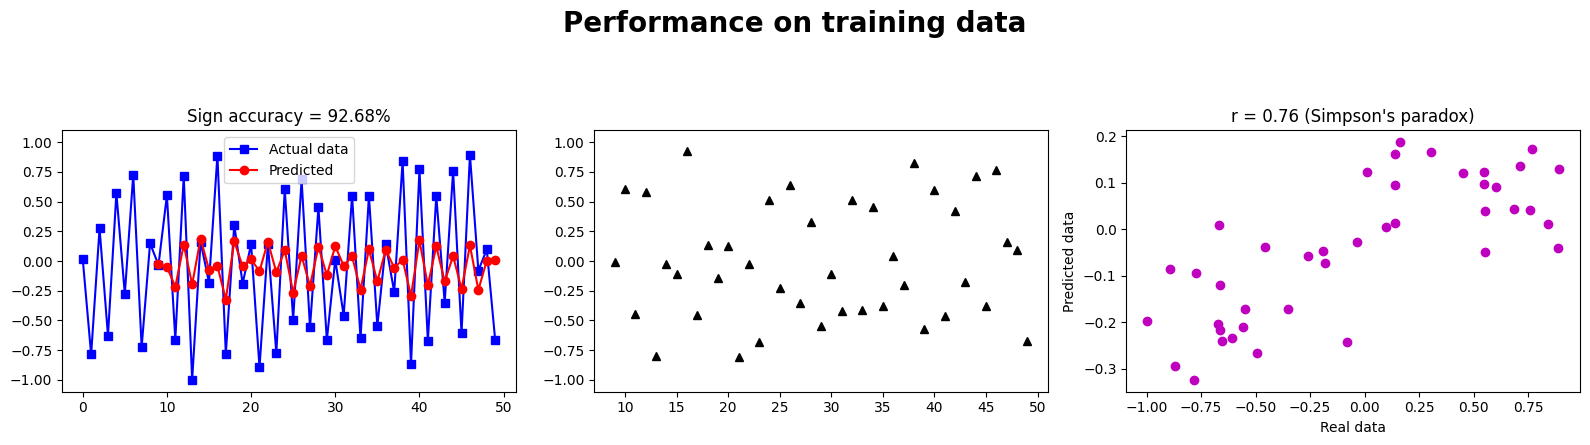

In [20]:
_, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(data_np, 'bs-', label="Actual data")
ax[0].plot(y_pred, 'ro-', label='Predicted')
ax[0].set_ylim([-1.1, 1.1])
ax[0].set_title(f"Sign accuracy = {sign_accuracies:.2f}%")
ax[0].legend()

ax[1].plot(data_np - y_pred, 'k^')
ax[1].set_ylim([-1.1, 1.1])

ax[2].plot(data_np[sequence_size:], y_pred[sequence_size:], 'mo')
ax[2].set_xlabel("Real data")
ax[2].set_ylabel("Predicted data")
ax[2].set_title(f"r = {corr[0, 1]:.2f} (Simpson's paradox)")

plt.suptitle("Performance on training data", fontweight='bold', fontsize=20, y=1.1)
plt.tight_layout()

plt.show()

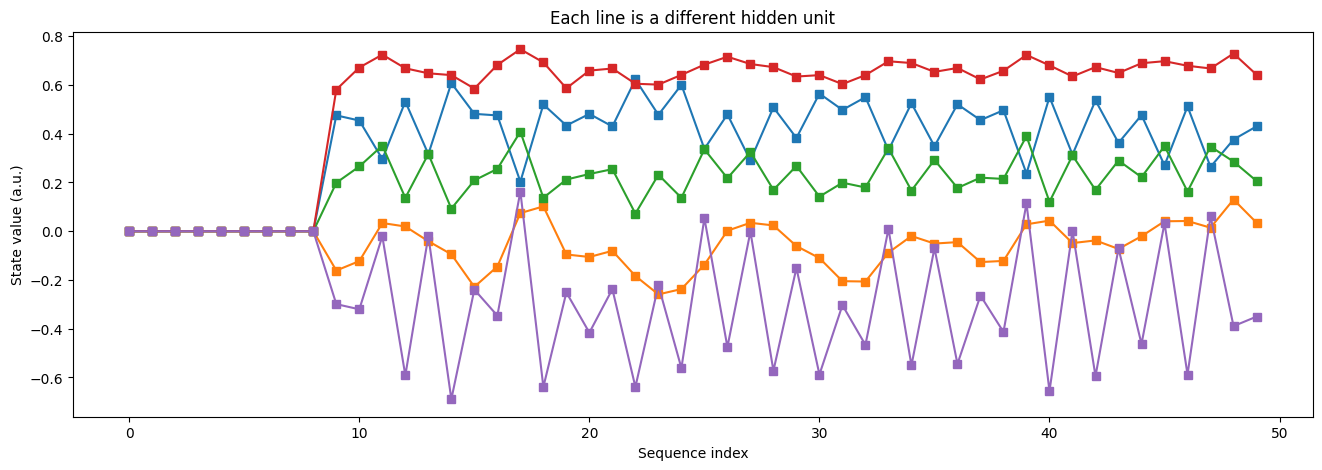

In [21]:
plt.figure(figsize=(16, 5))
plt.plot(hidden_layers, 's-')
plt.xlabel("Sequence index")
plt.ylabel("State value (a.u.)")
plt.title("Each line is a different hidden unit")

plt.show()

In [22]:
new_data = torch.zeros(sequence_full_size)

for i in range(sequence_full_size):
  new_data[i] = torch.rand(1) * (-1) ** (i + 1)

In [23]:
new_data_np = new_data.numpy().ravel()

hidden_layers = np.zeros((sequence_full_size, hidden_size))
y_pred = np.zeros(sequence_full_size)
y_pred[:] = np.nan

with torch.no_grad():
    for time_index in range(sequence_full_size - sequence_size):
        X = new_data[time_index:time_index + sequence_size].view(sequence_size, 1, 1)
        y_pred_temp, hidden_layer = rnn_net(X)
        y_pred[time_index + sequence_size] = y_pred_temp[-1].item()
        hidden_layers[time_index + sequence_size, :] = hidden_layer.numpy().ravel()

true_signs = np.sign(new_data_np)
pred_signs = np.sign(y_pred)
sign_accuracies = 100 * np.mean(true_signs[sequence_size:] == pred_signs[sequence_size:])

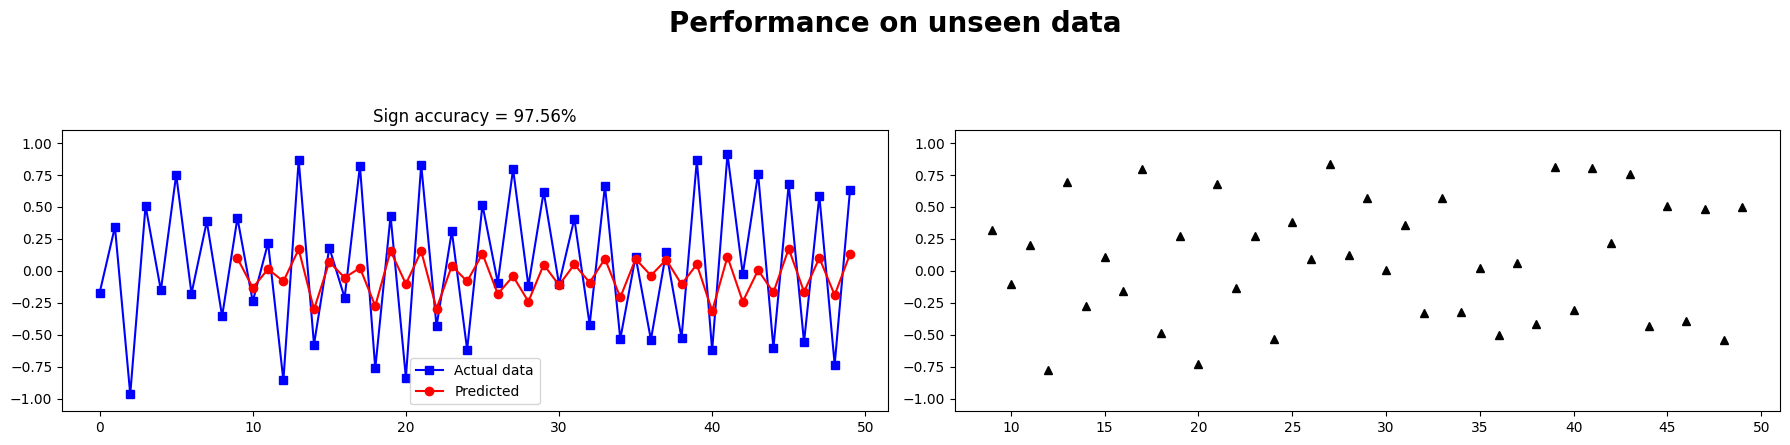

In [24]:
_, ax = plt.subplots(1, 2, figsize=(18, 4))

ax[0].plot(new_data_np, 'bs-', label="Actual data")
ax[0].plot(y_pred, 'ro-', label='Predicted')
ax[0].set_ylim([-1.1, 1.1])
ax[0].set_title(f"Sign accuracy = {sign_accuracies:.2f}%")
ax[0].legend()

ax[1].plot(new_data_np - y_pred, 'k^')
ax[1].set_ylim([-1.1, 1.1])

plt.suptitle("Performance on unseen data", fontweight='bold', fontsize=20, y=1.1)
plt.tight_layout()

plt.show()

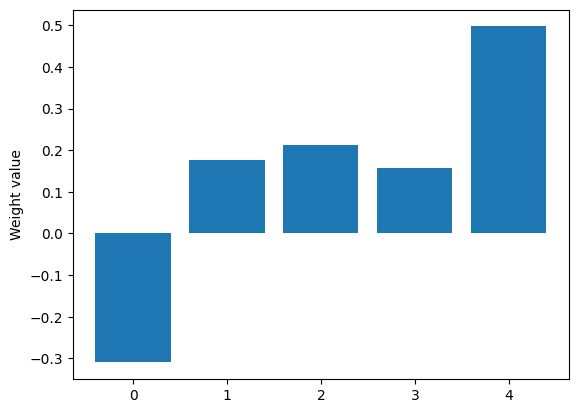

In [25]:
plt.bar(range(hidden_size), rnn_net.rnn.weight_ih_l0.detach().numpy().ravel())
plt.ylabel("Weight value")

plt.show()

## CodeChallenge: sine wave extrapolation

In [26]:
sequence_full_size = 500
sequence = np.linspace(0, 30 * np.pi, sequence_full_size)

data = torch.zeros(sequence_full_size)

for index, value in enumerate(sequence):
    data[index] = np.sin(value + np.cos(value)) 

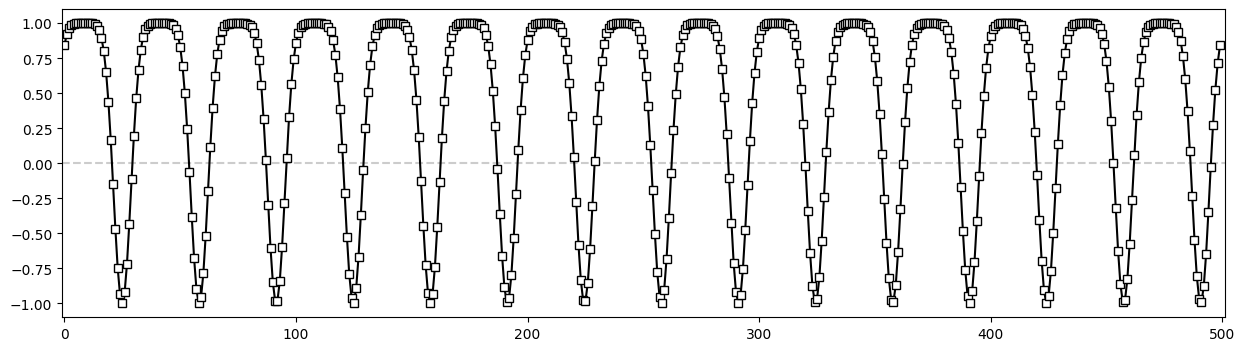

In [27]:
plt.figure(figsize=(15, 4))
plt.plot([-1, sequence_full_size + 1], [0, 0], '--', color=[.8, .8, .8])
plt.plot(data, 'ks-', markerfacecolor='w')
plt.xlim([-1, sequence_full_size + 1])
plt.show()

In [28]:
def train_model(data_param, sequence_size_param, epochs_nr_param, rnn_net_param, optimizer_param, loss_function_param):
    losses_local = np.zeros(epochs_nr_param)
    sign_accuracies_local = np.zeros(epochs_nr_param)

    for epoch_local in range(epochs_nr_param):
        segment_losses_local = []
        segment_sign_accuracies_local = []
        hidden_layer_local = None

        for time_index_local in range(len(data_param) - sequence_size_param):
            X_local = data_param[time_index_local:time_index_local + sequence_size_param].view(sequence_size_param, 1, 1)
            y_local = data_param[time_index_local + sequence_size_param].view(1, 1)

            y_pred_local, hidden_layer_local = rnn_net_param(X_local, hidden_layer_local)
            y_pred_local = y_pred_local[-1]
            loss_local = loss_function_param(y_pred_local, y_local)

            optimizer_param.zero_grad()
            loss_local.backward()
            optimizer_param.step()

            segment_losses_local.append(loss_local.item())

            pred_signs_local = np.sign(torch.squeeze(y_pred_local).detach().numpy())
            true_signs_local = np.sign(torch.squeeze(y_local).numpy())
            segment_sign_accuracy_local = 100 * (true_signs_local == pred_signs_local)

            segment_sign_accuracies_local.append(segment_sign_accuracy_local)

        losses_local[epoch_local] = np.mean(segment_losses_local)
        sign_accuracies_local[epoch_local] = np.mean(segment_sign_accuracies_local)

    return losses_local, sign_accuracies_local

In [29]:
hidden_size = 9
sequence_size = 30
epochs_nr = 30
rnn_net = RnnNet(input_size, hidden_size, layers_nr)
optimizer = torch.optim.SGD(rnn_net.parameters(), lr = .001)
loss_function = nn.MSELoss()

losses, sign_accuracies = train_model(data, sequence_size, epochs_nr, rnn_net, optimizer, loss_function)

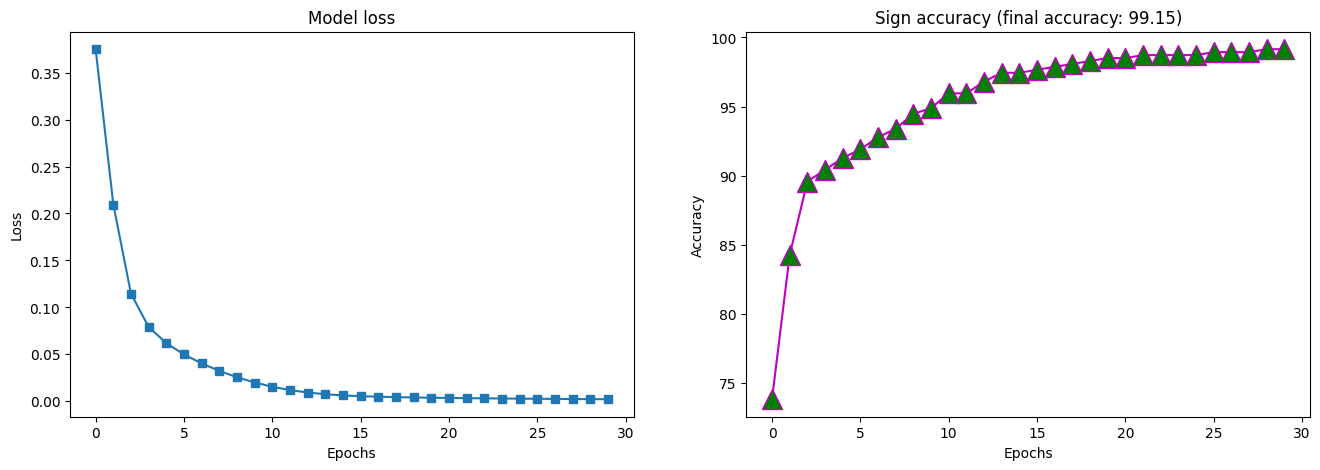

In [30]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(losses, 's-')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")

ax[1].plot(sign_accuracies, 'm^-', markerfacecolor='g', markersize=15)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_title(f"Sign accuracy (final accuracy: {sign_accuracies[-1]:.2f})")

plt.show()

In [31]:
def evaluate_model(data_param, sequence_size_param, rnn_net_param):
    data_np_local = data_param.numpy().ravel()
    data_size_local = len(data_param)

    y_pred_local = np.zeros(data_size_local)
    y_pred_local[:] = np.nan
    hidden_layer_local = None

    with torch.no_grad():
        for time_index_local in range(data_size_local - sequence_size_param):
            X_local = data_param[time_index_local:time_index_local + sequence_size_param].view(sequence_size_param, 1, 1)
            y_pred_temp_local, hidden_layer_local = rnn_net_param(X_local, hidden_layer_local)
            y_pred_local[time_index_local + sequence_size_param] = y_pred_temp_local[-1].item()

    true_signs_local = np.sign(data_np_local)
    pred_signs_local = np.sign(y_pred_local)
    sign_accuracies_local = 100 * np.mean(true_signs_local[sequence_size_param:] == pred_signs_local[sequence_size_param:])

    return data_np_local, y_pred_local, sign_accuracies_local

In [32]:
def plot(data_param, y_pred_param, sign_accuracies_param=None):
    plt.figure(figsize=(16, 4))
    plt.plot(data_param, 'bs-', label="Actual data")
    plt.plot(y_pred_param, 'ro-', label='Predicted')
    plt.ylim([-1.1, 1.1])
    
    if sign_accuracies_param:
        plt.title(f"Sign accuracy = {sign_accuracies_param:.2f}%")

    plt.legend()
    
    plt.show()

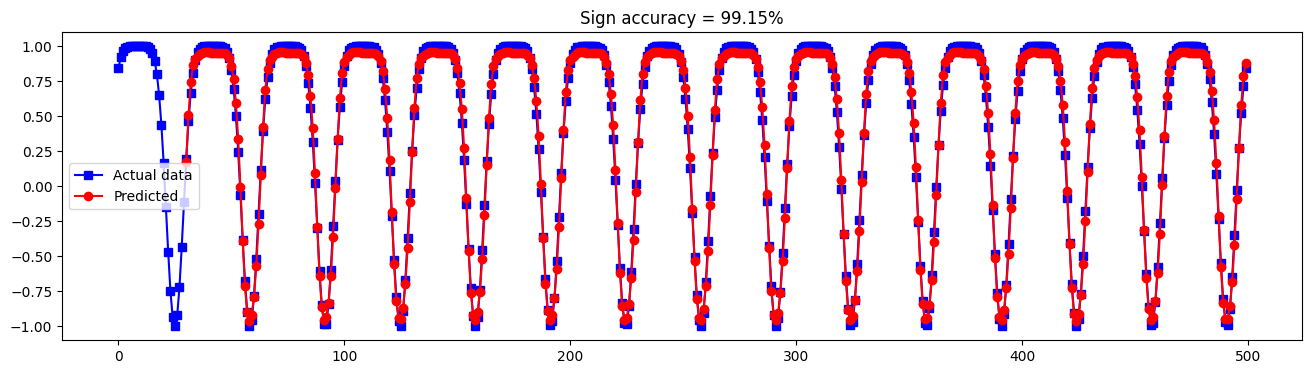

In [33]:
data_np, y_pred, sign_accuracies = evaluate_model(data, sequence_size, rnn_net)

plot(data_np, y_pred, sign_accuracies)

In [34]:
sequence_2 = np.linspace(0, 10 * np.pi, sequence_full_size)

data_2 = torch.zeros(sequence_full_size)

for index, value in enumerate(sequence_2):
    data_2[index] = np.sin(value + np.cos(value)) 

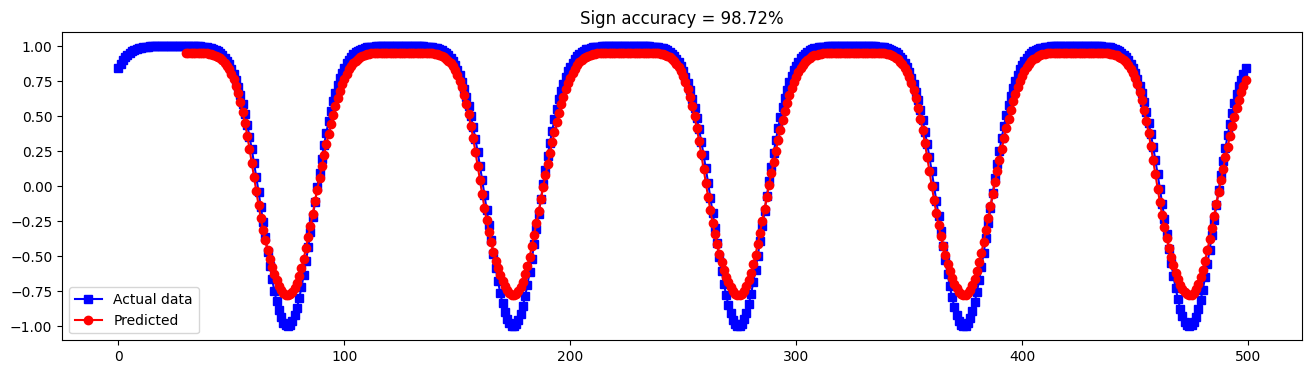

In [35]:
data_np_2, y_pred_2, sign_accuracies_2 = evaluate_model(data_2, sequence_size, rnn_net)

plot(data_np_2, y_pred_2, sign_accuracies_2)

In [36]:
sequence_3 = np.linspace(0, 30 * np.pi, sequence_full_size)

data_3 = torch.zeros(sequence_full_size)

for index, value in enumerate(sequence_3):
    data_3[index] = np.sin(value + np.sin(value)) 

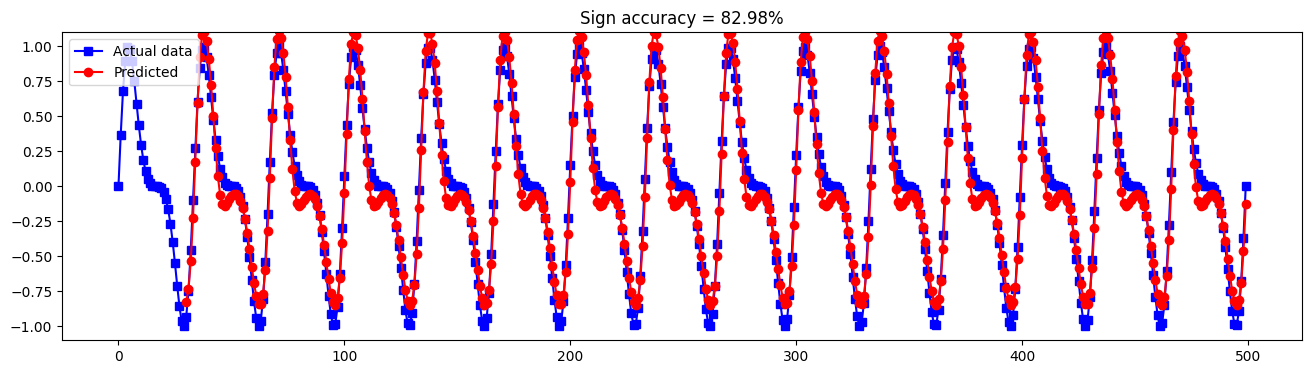

In [37]:
data_np_3, y_pred_3, sign_accuracies_3 = evaluate_model(data_3, sequence_size, rnn_net)

plot(data_np_3, y_pred_3, sign_accuracies_3)

In [38]:
def extrapolate_model(data_param, sequence_size_param, rnn_net_param):
    data_np_local = data_param.numpy().ravel()
    data_size_local = len(data_param)

    y_pred_local = np.zeros(data_size_local * 2)
    y_pred_local[:] = np.nan
    X_local = data_param[:sequence_size_param].view(sequence_size_param, 1, 1)
    hidden_layer_local = None

    with torch.no_grad():
        for time_index_local in range((data_size_local * 2) - sequence_size_param):
            y_pred_temp_local, hidden_layer_local = rnn_net_param(X_local, hidden_layer_local)
            y_pred_local[time_index_local + sequence_size_param] = y_pred_temp_local[-1].item()
            X_local = torch.cat((X_local[1:], torch.unsqueeze(y_pred_temp_local[-1], dim = 0)))

    return data_np_local, y_pred_local

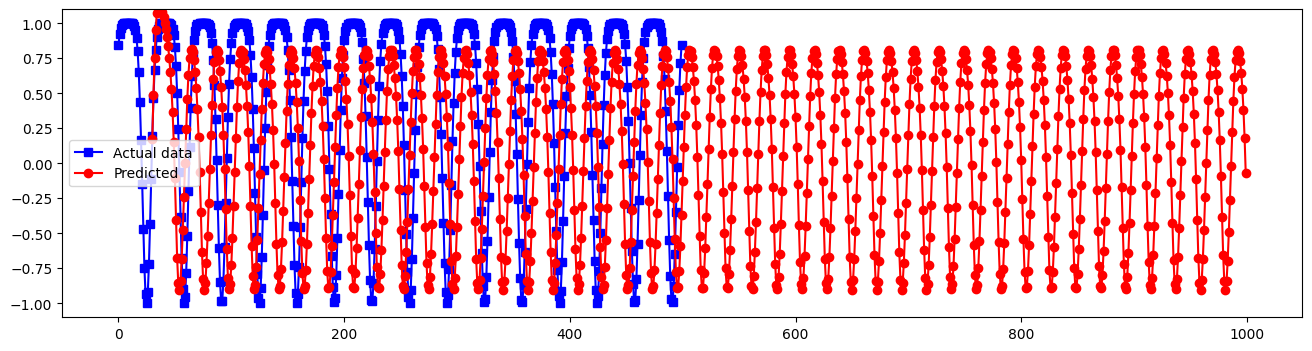

In [39]:
data_np, y_pred = extrapolate_model(data, sequence_size, rnn_net)

plot(data_np, y_pred)

## The LSTM and GRU classes

In [40]:
input_size = 9
hidden_size = 16
layers_nr = 2

gru = nn.GRU(input_size, hidden_size, layers_nr)

print(gru)

GRU(9, 16, num_layers=2)


In [41]:
sequence_size = 5
batch_size = 2

X = torch.rand(sequence_size, batch_size, input_size)
hidden_layer = torch.zeros(layers_nr, batch_size, hidden_size)

y_pred, hidden_layer = gru(X, hidden_layer)

print(f"Input shape: {list(X.shape)}")
print(f"Hidden shape: {list(hidden_layer.shape)}")
print(f"Output shape: {list(y_pred.shape)}")

Input shape: [5, 2, 9]
Hidden shape: [2, 2, 16]
Output shape: [5, 2, 16]


In [42]:
for p in gru.named_parameters():
    print(f"{p[0]} has size {list(p[1].shape)}")

weight_ih_l0 has size [48, 9]
weight_hh_l0 has size [48, 16]
bias_ih_l0 has size [48]
bias_hh_l0 has size [48]
weight_ih_l1 has size [48, 16]
weight_hh_l1 has size [48, 16]
bias_ih_l1 has size [48]
bias_hh_l1 has size [48]


In [43]:
class GruNet(nn.Module):
    def __init__(self, input_size_param, hidden_size_param, layers_nr_param):
        super().__init__()
        
        self.input_size = input_size_param
        self.hidden_size = hidden_size_param
        self.layers_nr = layers_nr_param
        
        self.gru = nn.GRU(input_size_param, hidden_size_param, layers_nr_param)
        self.output = nn.Linear(hidden_size_param, 1)
        
    def forward(self, x_param):
        print(f"Input: {list(x_param.shape)}")
        
        y_pred_local, hidden_layer_local = self.gru(x_param)
        
        print(f"GRU output: {list(y_pred_local.shape)}")
        print(f"GRU hidden: {list(hidden_layer_local.shape)}")
        
        output_local = self.output(y_pred_local)
        
        print(f"Output: {list(output_local.shape)}")
        
        return output_local, hidden_layer_local

In [44]:
gru_net = GruNet(input_size, hidden_size, layers_nr)

print(gru_net)

GruNet(
  (gru): GRU(9, 16, num_layers=2)
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [45]:
for p in gru_net.named_parameters():
    print(f"{p[0]} has size {list(p[1].shape)}")

gru.weight_ih_l0 has size [48, 9]
gru.weight_hh_l0 has size [48, 16]
gru.bias_ih_l0 has size [48]
gru.bias_hh_l0 has size [48]
gru.weight_ih_l1 has size [48, 16]
gru.weight_hh_l1 has size [48, 16]
gru.bias_ih_l1 has size [48]
gru.bias_hh_l1 has size [48]
output.weight has size [1, 16]
output.bias has size [1]


In [46]:
X = torch.rand(sequence_size, batch_size, input_size)
y = torch.rand(sequence_size, batch_size, 1)

y_pred, _ = gru_net(X)

Input: [5, 2, 9]
GRU output: [5, 2, 16]
GRU hidden: [2, 2, 16]
Output: [5, 2, 1]


In [47]:
loss_function = nn.MSELoss()

loss_function(y_pred, y)

tensor(0.3017, grad_fn=<MseLossBackward0>)

In [48]:
input_size = 9
hidden_size = 16
layers_nr = 2

lstm = nn.LSTM(input_size, hidden_size, layers_nr)

print(lstm)

LSTM(9, 16, num_layers=2)


In [49]:
sequence_size = 5
batch_size = 2

X = torch.rand(sequence_size, batch_size, input_size)
hidden_layer = torch.zeros(layers_nr, batch_size, hidden_size)
cell_layer = torch.zeros(layers_nr, batch_size, hidden_size)
hidden_inputs = (hidden_layer, cell_layer)

y_pred, hidden_layers = lstm(X, hidden_inputs)

print(f"Input shape: {list(X.shape)}")
print(f"Hidden shape: {list(hidden_layers[0].shape)}")
print(f"Cell shape: {list(hidden_layers[1].shape)}")
print(f"Output shape: {list(y_pred.shape)}")

Input shape: [5, 2, 9]
Hidden shape: [2, 2, 16]
Cell shape: [2, 2, 16]
Output shape: [5, 2, 16]


In [50]:
for p in lstm.named_parameters():
    print(f"{p[0]} has size {list(p[1].shape)}")

weight_ih_l0 has size [64, 9]
weight_hh_l0 has size [64, 16]
bias_ih_l0 has size [64]
bias_hh_l0 has size [64]
weight_ih_l1 has size [64, 16]
weight_hh_l1 has size [64, 16]
bias_ih_l1 has size [64]
bias_hh_l1 has size [64]


In [51]:
class LstmNet(nn.Module):
    def __init__(self, input_size_param, hidden_size_param, layers_nr_param):
        super().__init__()
        
        self.input_size = input_size_param
        self.hidden_size = hidden_size_param
        self.layers_nr = layers_nr_param
        
        self.lstm = nn.LSTM(input_size_param, hidden_size_param, layers_nr_param)
        self.output = nn.Linear(hidden_size_param, 1)
        
    def forward(self, x_param):
        print(f"Input: {list(x_param.shape)}")
        
        y_pred_local, hidden_layers_local = self.lstm(x_param)
        
        print(f"LSTM output: {list(y_pred_local.shape)}")
        print(f"LSTM hidden: {list(hidden_layers_local[0].shape)}")
        print(f"LSTM cell: {list(hidden_layers_local[1].shape)}")
        
        output_local = self.output(y_pred_local)
        
        print(f"Output: {list(output_local.shape)}")
        
        return output_local, hidden_layers_local

In [52]:
lstm_net = LstmNet(input_size, hidden_size, layers_nr)

print(lstm_net)

LstmNet(
  (lstm): LSTM(9, 16, num_layers=2)
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [53]:
for p in lstm_net.named_parameters():
    print(f"{p[0]} has size {list(p[1].shape)}")

lstm.weight_ih_l0 has size [64, 9]
lstm.weight_hh_l0 has size [64, 16]
lstm.bias_ih_l0 has size [64]
lstm.bias_hh_l0 has size [64]
lstm.weight_ih_l1 has size [64, 16]
lstm.weight_hh_l1 has size [64, 16]
lstm.bias_ih_l1 has size [64]
lstm.bias_hh_l1 has size [64]
output.weight has size [1, 16]
output.bias has size [1]


In [54]:
X = torch.rand(sequence_size, batch_size, input_size)
y = torch.rand(sequence_size, batch_size, 1)

y_pred, _ = lstm_net(X)

Input: [5, 2, 9]
LSTM output: [5, 2, 16]
LSTM hidden: [2, 2, 16]
LSTM cell: [2, 2, 16]
Output: [5, 2, 1]


In [55]:
loss_function = nn.MSELoss()

loss_function(y_pred, y)

tensor(0.1693, grad_fn=<MseLossBackward0>)

## Lorem ipsum

In [56]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

In [57]:
text = "Lorem ipsum dolor sit amet, consectetur adipiscing elit. Nam fringilla nulla erat, laoreet viverra nulla accumsan ac. Integer cursus sapien et dictum tempus. Praesent vel sapien velit. Nulla facilisi. Quisque dictum pharetra sodales. Donec quis est augue. Ut eget sem dictum, gravida lorem laoreet, tincidunt mi. Mauris a ex eleifend, rutrum metus vitae, accumsan urna. Fusce consectetur a magna ut venenatis. Sed ut pretium dolor. Mauris maximus euismod lorem, et sollicitudin urna ultrices placerat. Sed et nisl consequat, auctor dui quis, fringilla ligula. Pellentesque viverra velit quis lorem porta elementum. Phasellus iaculis magna ante, id laoreet justo tempor a. Donec interdum aliquam urna sit amet elementum. Phasellus et volutpat ipsum. In in diam at nunc tempor gravida eget vitae augue. Praesent pulvinar nisl id ligula congue, eu tempus dolor sagittis. Pellentesque sit amet cursus massa. Duis vel tempus orci. Maecenas pharetra eleifend scelerisque. Nulla vitae tincidunt urna. Sed pulvinar pretium nisi sit amet ornare. Suspendisse mattis urna ac mauris ullamcorper, id pretium massa auctor. Fusce dignissim id ex sit amet lacinia. Etiam varius, nibh eu viverra lobortis, urna nulla mattis velit, non mollis libero ligula non leo. Quisque egestas lorem justo, quis convallis lacus accumsan in. Vivamus et pellentesque augue, id pulvinar libero. Etiam pharetra augue metus, eget semper orci fringilla eu. Quisque dignissim posuere risus feugiat viverra. Vivamus dui tellus, tristique eget ligula non, vestibulum bibendum neque. In pulvinar sagittis ligula vel viverra. Donec imperdiet dui id aliquet varius. In massa ante, fermentum sit amet commodo nec, efficitur at enim. Curabitur blandit, risus eleifend tincidunt sollicitudin, turpis sem congue massa, sit amet laoreet magna dui nec orci. Praesent imperdiet fermentum felis, sed suscipit est commodo id. Curabitur imperdiet in lorem at sollicitudin. Ut eu varius risus. Lorem ipsum dolor sit amet, consectetur adipiscing elit. Suspendisse finibus lorem eros, sit amet lacinia elit commodo at. Quisque tempor turpis sed placerat dictum. Nullam quis purus quis metus molestie venenatis. Proin ut pretium leo.".lower()

In [58]:
unique_characters = set(text)

unique_characters

{' ',
 ',',
 '.',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'x'}

In [59]:
number_to_character = dict(enumerate(unique_characters))
character_to_number = { character:index for index, character in number_to_character.items() }

print(character_to_number['e'])
print(number_to_character[4])

0
l


In [60]:
data = torch.zeros((len(text), 1), dtype=torch.int64, device=device)

for index, character in enumerate(text):
    data[index] = character_to_number[character]

print(data.shape)

torch.Size([2177, 1])


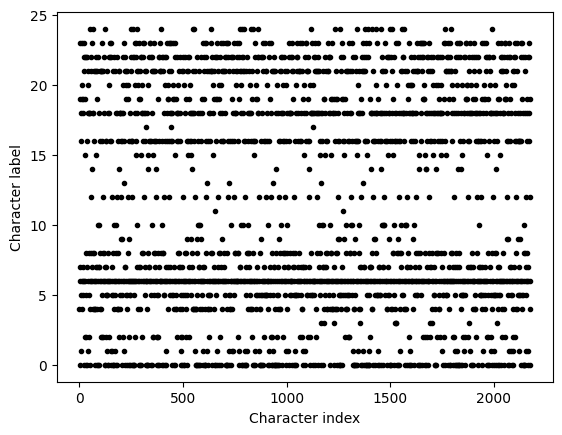

In [61]:
plt.plot(data.cpu().numpy(), 'k.')
plt.xlabel("Character index")
plt.ylabel("Character label")

plt.show()

In [62]:
class LstmNet(nn.Module):
    def __init__(self, input_size_param, output_size_param, hidden_size_param, layers_nr_param):
        super().__init__()
        
        self.embedding = nn.Embedding(input_size_param, input_size_param)
        self.lstm = nn.LSTM(input_size_param, hidden_size_param, layers_nr_param)
        self.output = nn.Linear(hidden_size_param, output_size_param)
        
    def forward(self, x_param, hidden_layer_param):
        
        embedding = self.embedding(x_param)
        y_pred_local, hidden_layer_local = self.lstm(embedding, hidden_layer_param)
        output_local = self.output(y_pred_local)
        
        return output_local, (hidden_layer_local[0].detach(), hidden_layer_local[1].detach())

In [63]:
hidden_size = 512
sequence_size = 80
layers_nr = 3
epochs_nr = 10

In [64]:
lstm_net = LstmNet(len(unique_characters), len(unique_characters), hidden_size, layers_nr).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_net.parameters(), lr=.001)

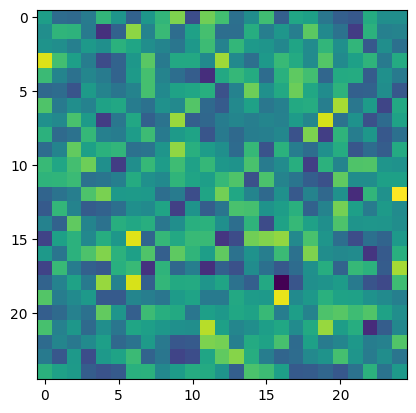

In [65]:
embeddings_matrix = next(lstm_net.embedding.named_parameters())

plt.imshow(embeddings_matrix[1].cpu().detach())
plt.show()

In [66]:
losses = np.zeros(epochs_nr)
steps_nr = len(text) - sequence_size

for epoch in range(epochs_nr):
    text_loss = 0
    
    for character_index in range(0, steps_nr):
        X_local = data[character_index:character_index + sequence_size]
        y_local = data[character_index + 1:character_index + sequence_size + 1]
        
        y_pred, _ = lstm_net(X_local, None)
        
        loss = loss_function(torch.squeeze(y_pred), torch.squeeze(y_local))
        text_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    losses[epoch] = text_loss / steps_nr

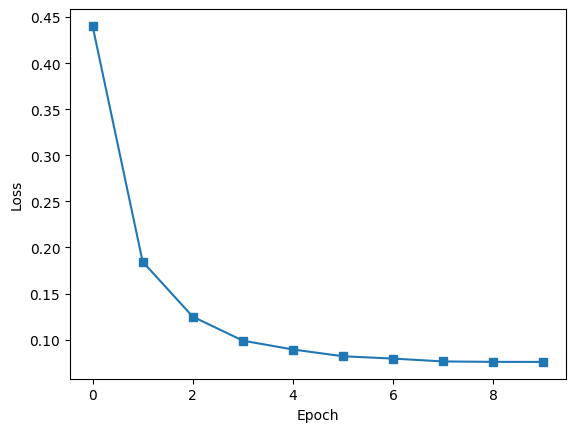

In [67]:
plt.plot(losses, 's-')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [68]:
generated_text_length = 200
X = torch.tensor(character_to_number['q']).view(1, 1).to(device)
generated_text = number_to_character[X.item()]

hidden_layer = None

for _ in range(generated_text_length):
    y_pred, hidden_layer = lstm_net(X, hidden_layer)
    
    index = torch.argmax(y_pred).item()
    X[0][0] = index
    
    generated_text += number_to_character[index]

In [69]:
generated_text

'quisque tempor turpis sed placerat dictum. nullam quis purus quis metus molestie venenatis. proin ut pretium leo. quisque tempor turpis sed placerat dictum. nullam quis purus quis metus molestie venena'

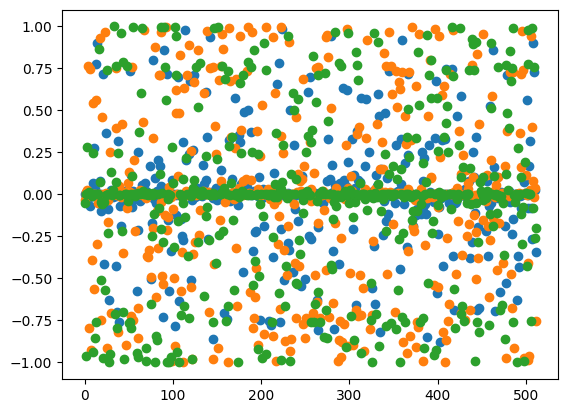

In [70]:
for i in range(layers_nr):
    plt.plot(hidden_layer[0][i, 0, :].cpu().numpy(), 'o')
    
plt.show()

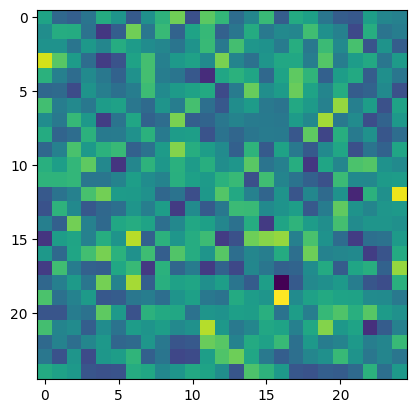

In [71]:
embeddings_matrix = next(lstm_net.embedding.named_parameters())
embeddings_matrix = embeddings_matrix[1].cpu().detach()

plt.imshow(embeddings_matrix)
plt.show()

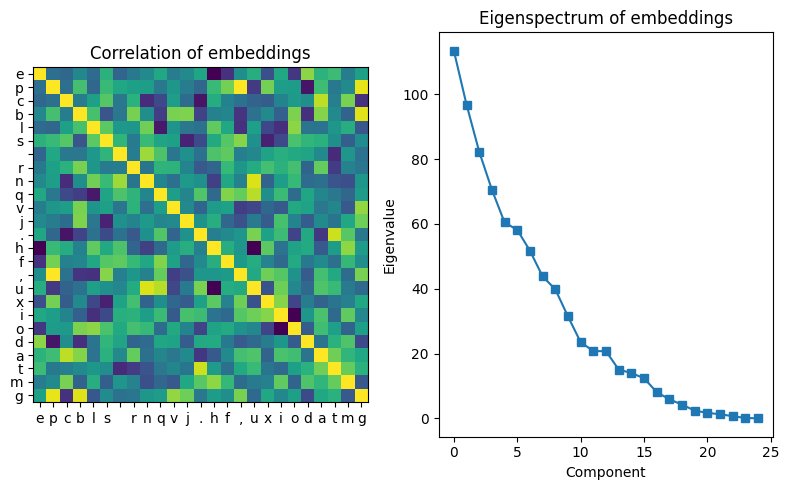

In [72]:
eigenvalues, _ = np.linalg.eigh(embeddings_matrix @ embeddings_matrix.T)
eigenvalues = eigenvalues[::-1]

_, axs = plt.subplots(1, 2, figsize=(8, 5))

axs[0].imshow(np.corrcoef(embeddings_matrix), vmin=-.5, vmax=.5)
axs[0].set_title("Correlation of embeddings")
axs[0].set_xticks(range(len(character_to_number.keys())))
axs[0].set_xticklabels(character_to_number.keys())
axs[0].set_yticks(range(len(character_to_number.keys())))
axs[0].set_yticklabels(character_to_number.keys())

axs[1].plot(eigenvalues, 's-')
axs[1].set_xlabel('Component')
axs[1].set_ylabel('Eigenvalue')
axs[1].set_title("Eigenspectrum of embeddings")

plt.tight_layout()
plt.show()